# Walmart M5 Forecasting Dataset: End-to-End EDA & Data Cleaning

**Author:** Data Analyst  
**Date:** July 2026  
**Dataset:** Walmart M5 Forecasting Dataset  
**Objective:** Perform comprehensive Exploratory Data Analysis (EDA) and Data Cleaning across all M5 dataset CSV files.

---

### Task Breakdown & Outline
1. **Task 1: Load CSV Files** - Extract raw CSV files (`calendar.csv`, `sell_prices.csv`, `sales_train_validation.csv`, `sales_train_evaluation.csv`, `sample_submission.csv`).
2. **Task 2: Handle Missing Values** - Identify null patterns and impute event categories.
3. **Task 3: Remove Duplicates** - Audit primary and composite key uniqueness.
4. **Task 4: Convert Dates** - Parse datetime structures and engineer calendar temporal features.
5. **Task 5: Check Data Consistency** - Validate value ranges, foreign key integrity, and temporal continuity.
6. **Task 6: Generate Descriptive Statistics** - Compute price distributions, store/category sales metrics, and zero-sales sparsity.
7. **Task 7: Generate Visualizations** - Render high-impact exploratory plots (time series, heatmaps, category breakdowns, SNAP & event impact analysis).


In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

# Styling configuration
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"font.size": 11, "axes.labelsize": 12, "axes.titlesize": 14, "figure.dpi": 150})

DATA_DIR = "../m5-forecasting-accuracy"
CLEANED_DIR = "../data/cleaned"
CHARTS_DIR = "../reports/charts"

print("Libraries imported and paths configured successfully.")


Libraries imported and paths configured successfully.


## Task 1: Load All CSV Files

We load sample rows and inspect structural metadata for all 5 M5 dataset CSV files:
- `calendar.csv`: Contains dates, holidays, events, and SNAP flags.
- `sell_prices.csv`: Contains weekly item price data per store.
- `sales_train_validation.csv`: Contains daily unit sales per item up to d_1913.
- `sales_train_evaluation.csv`: Contains daily unit sales per item up to d_1941.
- `sample_submission.csv`: Submission format specifications.


In [2]:
# Load raw CSV datasets
calendar_df = pd.read_csv(os.path.join(DATA_DIR, "calendar.csv"))
sell_prices_df = pd.read_csv(os.path.join(DATA_DIR, "sell_prices.csv"))
sales_eval_df = pd.read_csv(os.path.join(DATA_DIR, "sales_train_evaluation.csv"))
sales_val_df = pd.read_csv(os.path.join(DATA_DIR, "sales_train_validation.csv"))
sample_sub_df = pd.read_csv(os.path.join(DATA_DIR, "sample_submission.csv"))

print(f"Calendar shape: {calendar_df.shape}")
print(f"Sell Prices shape: {sell_prices_df.shape}")
print(f"Sales Evaluation shape: {sales_eval_df.shape}")
print(f"Sales Validation shape: {sales_val_df.shape}")
print(f"Sample Submission shape: {sample_sub_df.shape}")

display(calendar_df.head(3))
display(sell_prices_df.head(3))
display(sales_eval_df.head(3))


Calendar shape: (1969, 14)
Sell Prices shape: (6841121, 4)
Sales Evaluation shape: (30490, 1947)
Sales Validation shape: (30490, 1919)
Sample Submission shape: (60980, 29)


,date,wm_yr_wk,weekday,wday,month,year,d,event_name_1,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI
0,2011-01-29,11101,Saturday,1,1,2011,d_1,NaN,NaN,NaN,NaN,0,0,0
1,2011-01-30,11101,Sunday,2,1,2011,d_2,NaN,NaN,NaN,NaN,0,0,0
2,2011-01-31,11101,Monday,3,1,2011,d_3,NaN,NaN,NaN,NaN,0,0,0


,store_id,item_id,wm_yr_wk,sell_price
0,CA_1,HOBBIES_1_001,11325,9.58
1,CA_1,HOBBIES_1_001,11326,9.58
2,CA_1,HOBBIES_1_001,11327,8.26


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1932,d_1933,d_1934,d_1935,d_1936,d_1937,d_1938,d_1939,d_1940,d_1941
0,HOBBIES_1_001_CA_1_evaluation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,4,0,0,0,0,3,3,0,1
1,HOBBIES_1_002_CA_1_evaluation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,1,2,1,1,0,0,0,0,0
2,HOBBIES_1_003_CA_1_evaluation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,2,0,0,0,2,3,0,1


## Task 2: Audit and Handle Missing Values

Missing value analysis is conducted across all datasets.
In `calendar.csv`, missing values in `event_name_1`, `event_type_1`, `event_name_2`, and `event_type_2` occur on days without special events or holidays. These are imputed with the category `'None'`.


In [3]:
# Check missing values before cleaning
print("=== Calendar Missing Values (Before) ===")
print(calendar_df.isnull().sum()[calendar_df.isnull().sum() > 0])

# Impute event columns
event_cols = ["event_name_1", "event_type_1", "event_name_2", "event_type_2"]
for col in event_cols:
    calendar_df[col] = calendar_df[col].fillna("None")

print("\n=== Calendar Missing Values (After Imputation) ===")
print(calendar_df[event_cols].isnull().sum())

print("\n=== Sell Prices Missing Values ===")
print(sell_prices_df.isnull().sum())

print("\n=== Sales Evaluation Missing Values ===")
print(sales_eval_df[["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]].isnull().sum())


=== Calendar Missing Values (Before) ===
event_name_1    1807
event_type_1    1807
event_name_2    1964
event_type_2    1964
dtype: int64

=== Calendar Missing Values (After Imputation) ===
event_name_1    0
event_type_1    0
event_name_2    0
event_type_2    0
dtype: int64

=== Sell Prices Missing Values ===


store_id      0
item_id       0
wm_yr_wk      0
sell_price    0
dtype: int64

=== Sales Evaluation Missing Values ===
id          0
item_id     0
dept_id     0
cat_id      0
store_id    0
state_id    0
dtype: int64


## Task 3: Detect and Remove Duplicates

Primary key uniqueness checks:
- `calendar.csv`: Keyed by `d` and `date`.
- `sell_prices.csv`: Keyed by composite key (`store_id`, `item_id`, `wm_yr_wk`).
- `sales_train_evaluation.csv`: Keyed by `id`.


In [4]:
# Duplicate audit
cal_dups = calendar_df.duplicated(subset=["d"]).sum()
price_dups = sell_prices_df.duplicated(subset=["store_id", "item_id", "wm_yr_wk"]).sum()
sales_dups = sales_eval_df.duplicated(subset=["id"]).sum()

print(f"Calendar Duplicate Count (key='d'): {cal_dups}")
print(f"Sell Prices Duplicate Count (key='store_id, item_id, wm_yr_wk'): {price_dups}")
print(f"Sales Evaluation Duplicate Count (key='id'): {sales_dups}")

# Deduplicate if any duplicates exist
sell_prices_df = sell_prices_df.drop_duplicates(subset=["store_id", "item_id", "wm_yr_wk"])
print(f"Cleaned Sell Prices Row Count: {len(sell_prices_df):,}")


Calendar Duplicate Count (key='d'): 0
Sell Prices Duplicate Count (key='store_id, item_id, wm_yr_wk'): 0
Sales Evaluation Duplicate Count (key='id'): 0


Cleaned Sell Prices Row Count: 6,841,121


## Task 4: Date Conversions and Feature Parsing

Convert `date` in `calendar.csv` to `datetime64[ns]` and verify calendar day ordering.


In [5]:
# Convert date column to datetime
calendar_df["date"] = pd.to_datetime(calendar_df["date"])
calendar_df["is_weekend"] = calendar_df["wday"].isin([1, 2]).astype(int)

print("Date range in calendar:")
print(f"Start Date: {calendar_df['date'].min().strftime('%Y-%m-%d')}")
print(f"End Date:   {calendar_df['date'].max().strftime('%Y-%m-%d')}")
print(f"Total Calendar Days: {len(calendar_df)}")

display(calendar_df[["date", "wm_yr_wk", "weekday", "wday", "month", "year", "event_name_1", "is_weekend"]].head(5))


Date range in calendar:
Start Date: 2011-01-29
End Date:   2016-06-19
Total Calendar Days: 1969


,date,wm_yr_wk,weekday,wday,month,year,event_name_1,is_weekend
0,2011-01-29,11101,Saturday,1,1,2011,None,1
1,2011-01-30,11101,Sunday,2,1,2011,None,1
2,2011-01-31,11101,Monday,3,1,2011,None,0
3,2011-02-01,11101,Tuesday,4,2,2011,None,0
4,2011-02-02,11101,Wednesday,5,2,2011,None,0


## Task 5: Data Consistency & Integrity Audit

Validation of domain constraints:
1. Sell price positivity (`sell_price > 0`).
2. Sales quantity non-negativity (`sales_qty >= 0`).
3. Store, Category, Department, and State entity cardinalities.
4. Day index continuity (`d_1` to `d_1941`).


In [6]:
# 1. Price integrity check
invalid_prices = (sell_prices_df["sell_price"] <= 0).sum()
print(f"Invalid Prices (sell_price <= 0): {invalid_prices}")

# 2. Daily sales non-negativity check
d_cols = [c for c in sales_eval_df.columns if c.startswith("d_")]
negative_sales = (sales_eval_df[d_cols] < 0).sum().sum()
print(f"Negative Daily Sales Quantity Count: {negative_sales}")

# 3. Entity cardinality audit
print("\nUnique Entity Counts:")
print(f"Stores:       {sales_eval_df['store_id'].nunique()} -> {sorted(sales_eval_df['store_id'].unique())}")
print(f"States:       {sales_eval_df['state_id'].nunique()} -> {sorted(sales_eval_df['state_id'].unique())}")
print(f"Categories:   {sales_eval_df['cat_id'].nunique()} -> {sorted(sales_eval_df['cat_id'].unique())}")
print(f"Departments:  {sales_eval_df['dept_id'].nunique()} -> {sorted(sales_eval_df['dept_id'].unique())}")
print(f"Items:        {sales_eval_df['item_id'].nunique()}")

# 4. Day column sequence check
expected_d_cols = [f"d_{i}" for i in range(1, 1942)]
print(f"\nAll 1,941 day columns present in order: {d_cols == expected_d_cols}")


Invalid Prices (sell_price <= 0): 0


Negative Daily Sales Quantity Count: 0

Unique Entity Counts:
Stores:       10 -> ['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2', 'WI_3']
States:       3 -> ['CA', 'TX', 'WI']
Categories:   3 -> ['FOODS', 'HOBBIES', 'HOUSEHOLD']
Departments:  7 -> ['FOODS_1', 'FOODS_2', 'FOODS_3', 'HOBBIES_1', 'HOBBIES_2', 'HOUSEHOLD_1', 'HOUSEHOLD_2']
Items:        3049

All 1,941 day columns present in order: True


## Task 6: Generate Descriptive Statistics

Statistical summaries of pricing, overall unit sales, category-level distribution, and sparsity (zero-sales ratio).


In [7]:
# Summary statistics for Sell Prices by Category
merged_prices = sell_prices_df.merge(
    sales_eval_df[["item_id", "cat_id", "dept_id"]].drop_duplicates(),
    on="item_id",
    how="inner"
)

price_summary = merged_prices.groupby("cat_id")["sell_price"].describe()
display(price_summary)

# Sales Volume Summary by Store
sales_eval_df["total_units"] = sales_eval_df[d_cols].sum(axis=1)
store_summary = sales_eval_df.groupby(["state_id", "store_id"])["total_units"].agg(
    item_count="count",
    total_sales="sum",
    mean_sales_per_item="mean",
    median_sales_per_item="median",
    std_sales_per_item="std"
).reset_index()

display(store_summary)

# Zero Sales Sparsity
zero_sales_count = (sales_eval_df[d_cols] == 0).sum().sum()
total_sales_cells = len(sales_eval_df) * len(d_cols)
sparsity_pct = (zero_sales_count / total_sales_cells) * 100

print(f"\nTotal Time Series Cells: {total_sales_cells:,}")
print(f"Zero Sales Cells:       {zero_sales_count:,}")
print(f"Dataset Sparsity Ratio:  {sparsity_pct:.2f}% zero-sales days")


,count,mean,std,min,25%,50%,75%,max
cat_id,,,,,,,,
FOODS,3181789.0,3.251027,2.132220,0.01,1.98,2.68,3.98,19.48
HOBBIES,1283905.0,5.333896,4.828999,0.01,1.97,3.97,7.47,30.98
HOUSEHOLD,2375427.0,5.465780,3.375843,0.01,2.98,4.94,6.97,107.32


,state_id,store_id,item_count,total_sales,mean_sales_per_item,median_sales_per_item,std_sales_per_item
0,CA,CA_1,3049,7832248,2568.792391,1149.0,5422.759182
1,CA,CA_2,3049,5818395,1908.296163,889.0,3347.177542
2,CA,CA_3,3049,11363540,3726.972778,1505.0,8581.106514
3,CA,CA_4,3049,4182534,1371.772384,660.0,2447.806317
4,TX,TX_1,3049,5692823,1867.111512,694.0,4552.299273
5,TX,TX_2,3049,7329642,2403.949492,927.0,6505.105845
6,TX,TX_3,3049,6205940,2035.401771,741.0,5518.222694
7,WI,WI_1,3049,5261506,1725.649721,867.0,3067.682746
8,WI,WI_2,3049,6697988,2196.781896,771.0,4712.938219
9,WI,WI_3,3049,6542557,2145.804198,727.0,5565.160045



Total Time Series Cells: 59,181,090
Zero Sales Cells:       40,241,819
Dataset Sparsity Ratio:  68.00% zero-sales days


## Task 7: Generate Exploratory Visualizations

We render and display the 7 key analytical visual charts generated by the EDA pipeline.


=== 1. Aggregate Daily & 28-Day Rolling Average Sales ===


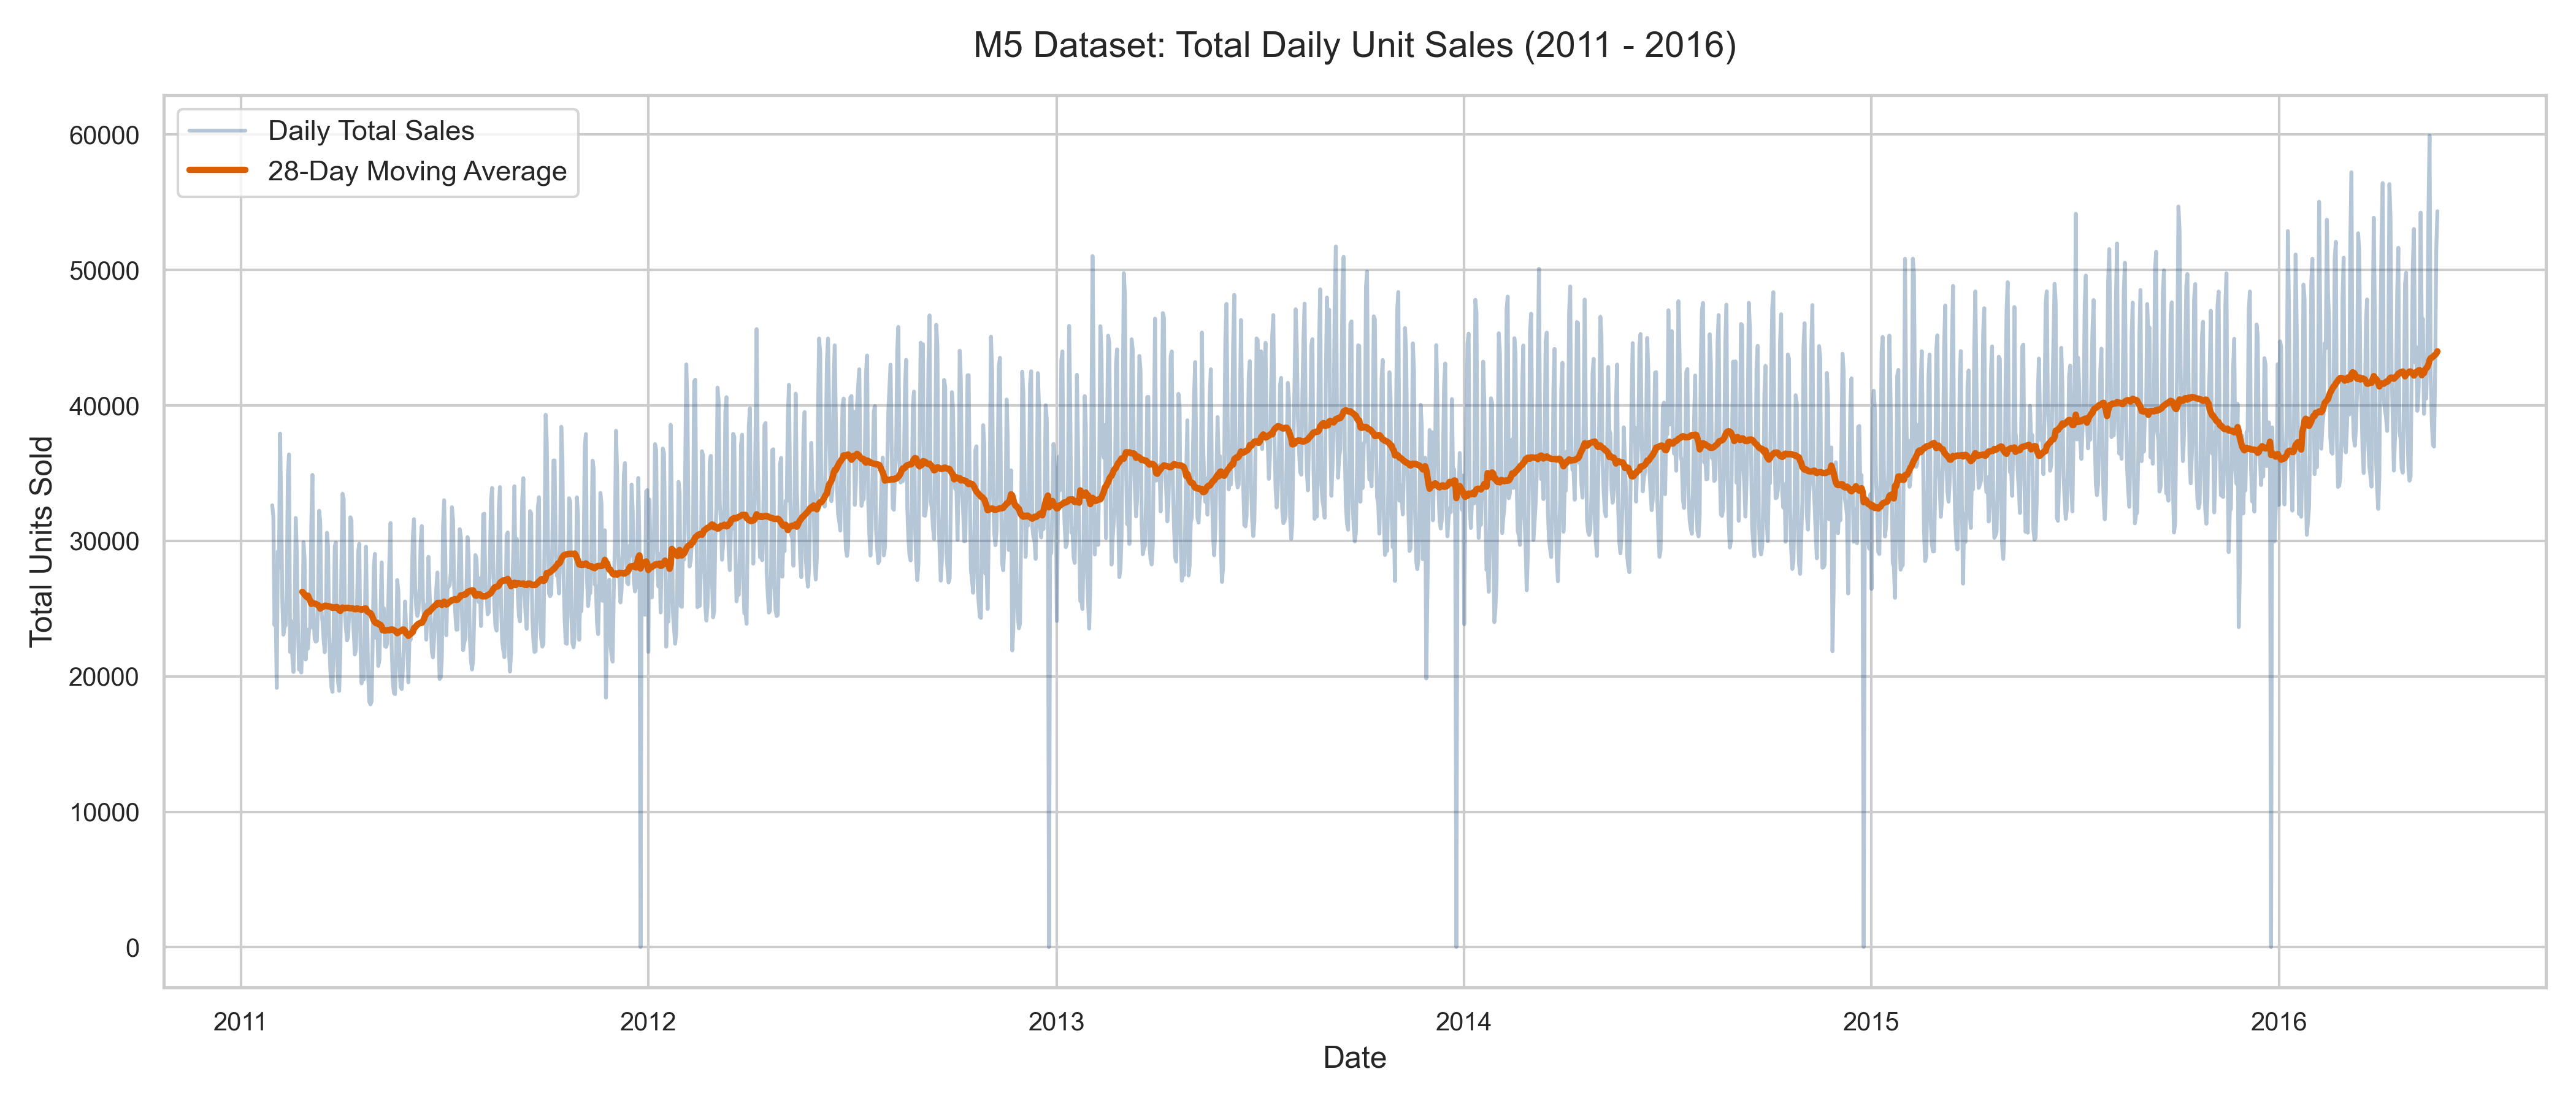

=== 2. Total Unit Sales by Category & State ===


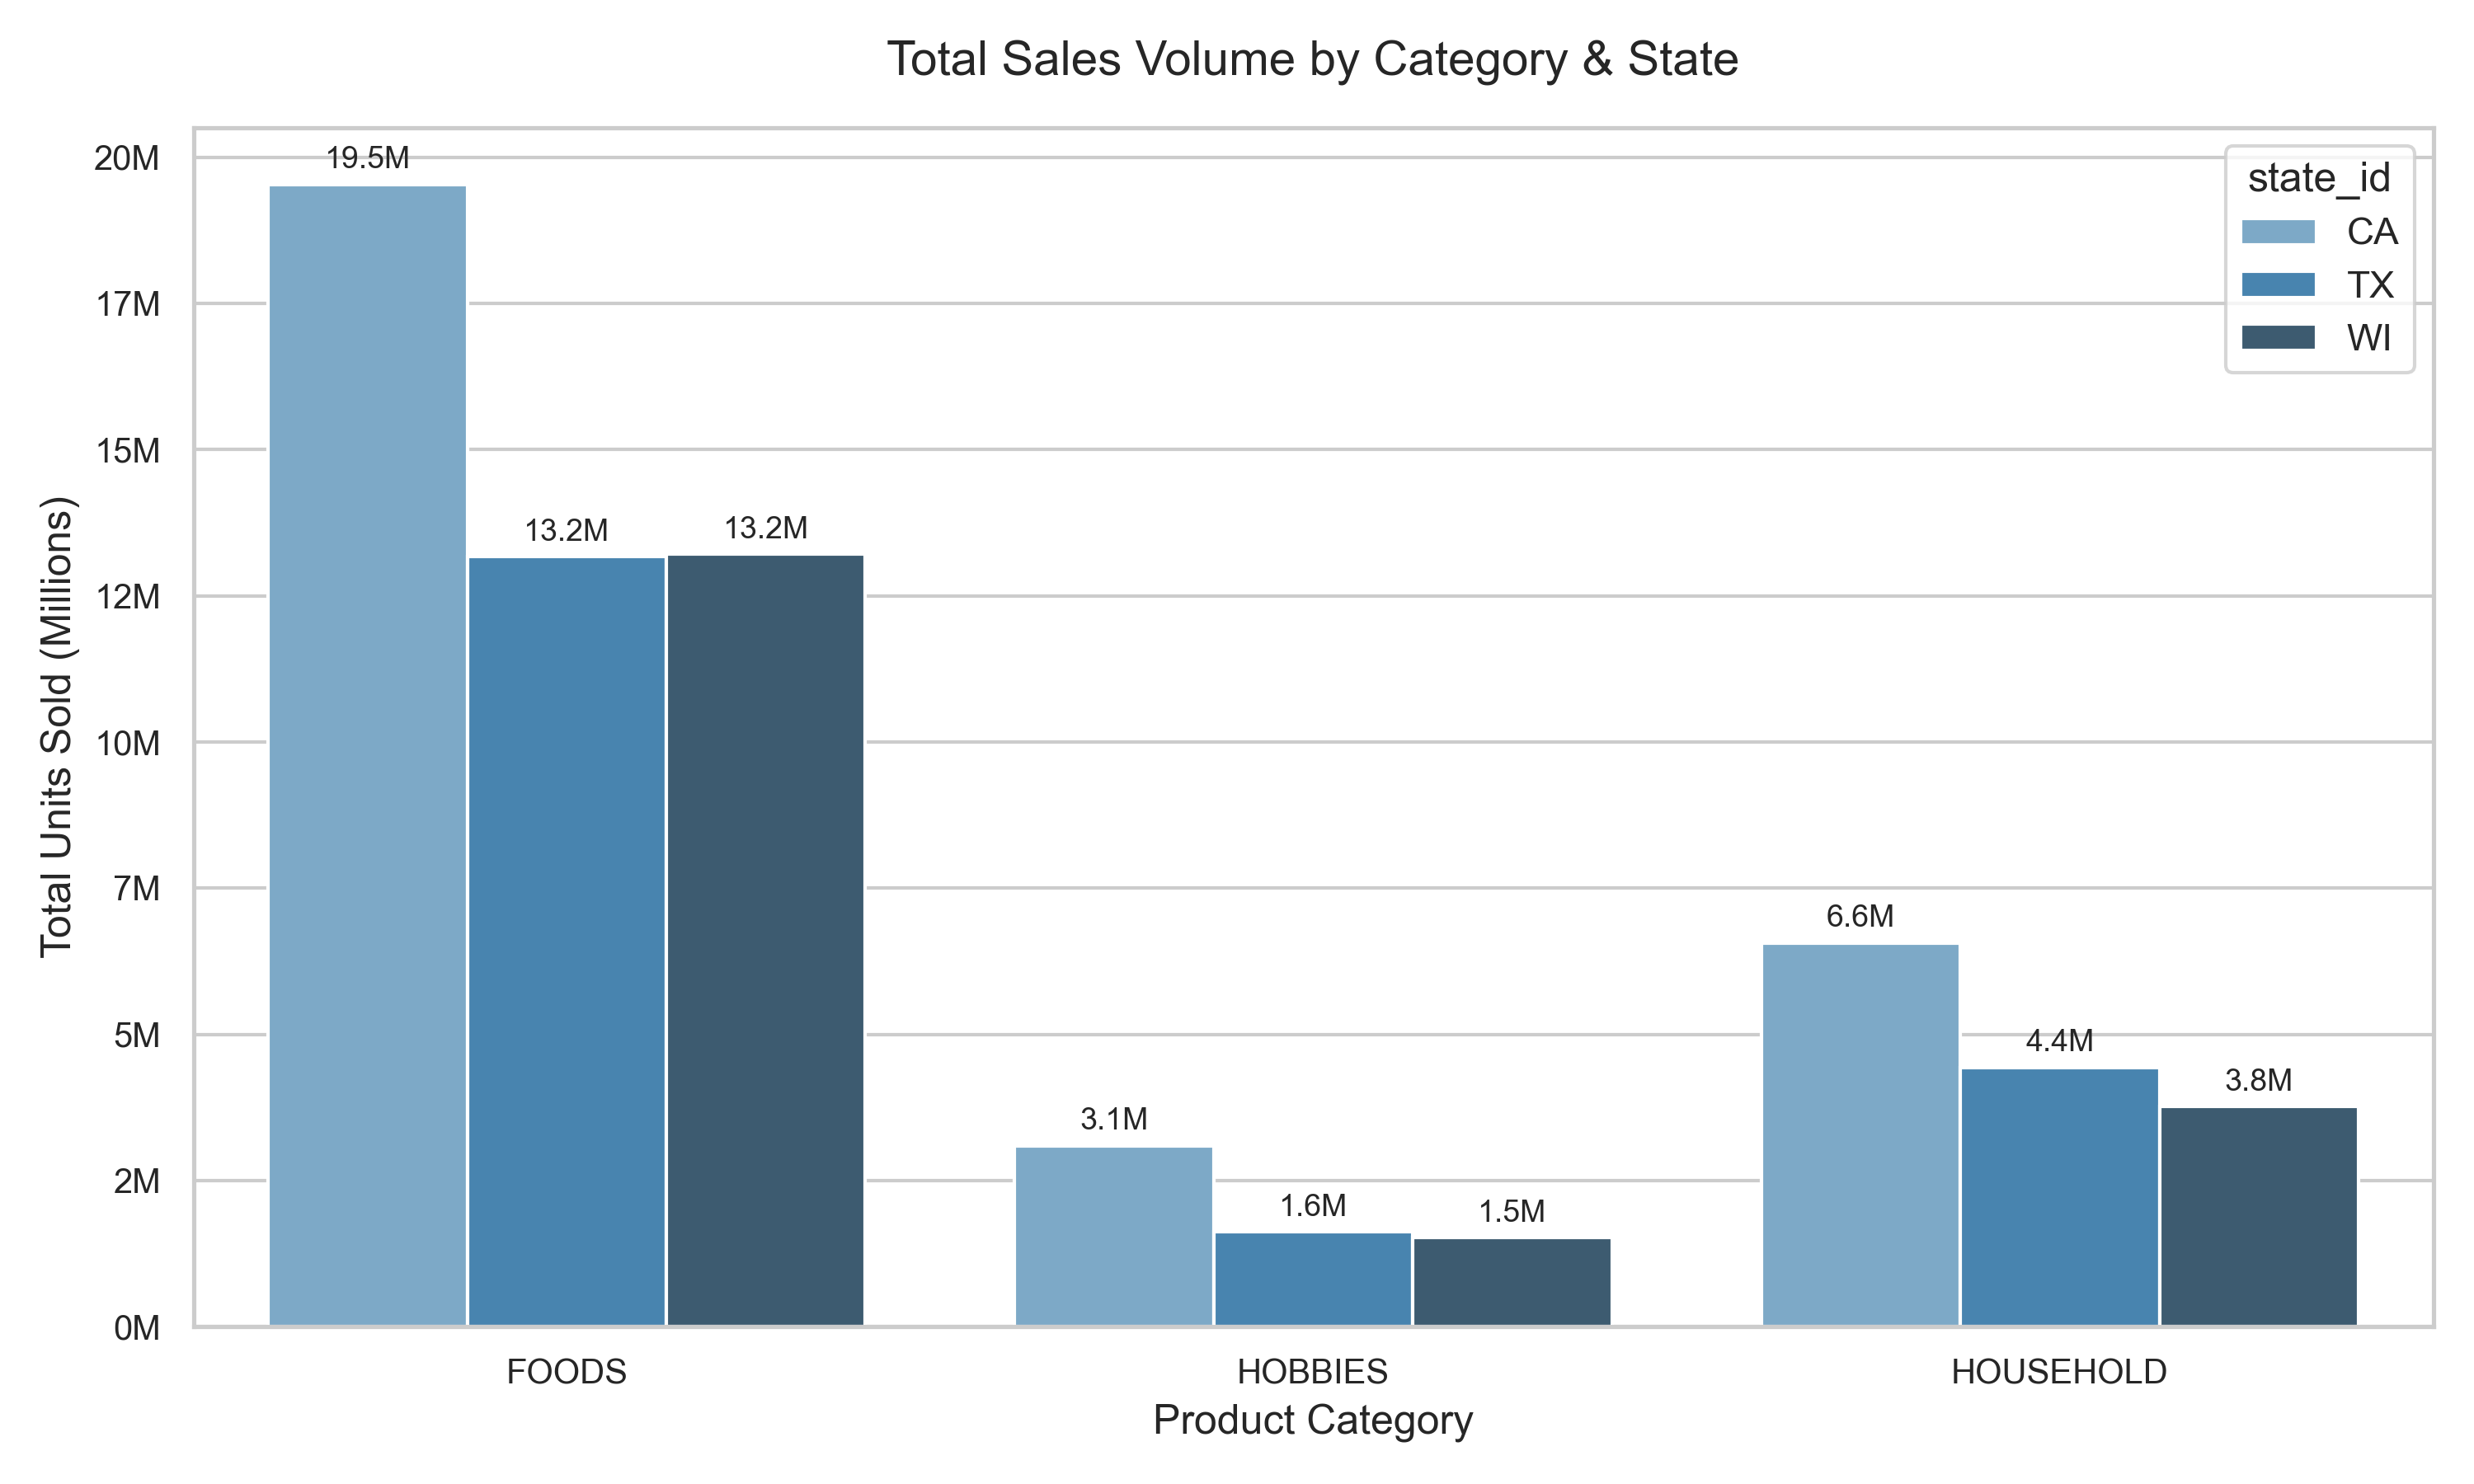

=== 3. Sell Price Distribution by Category ===


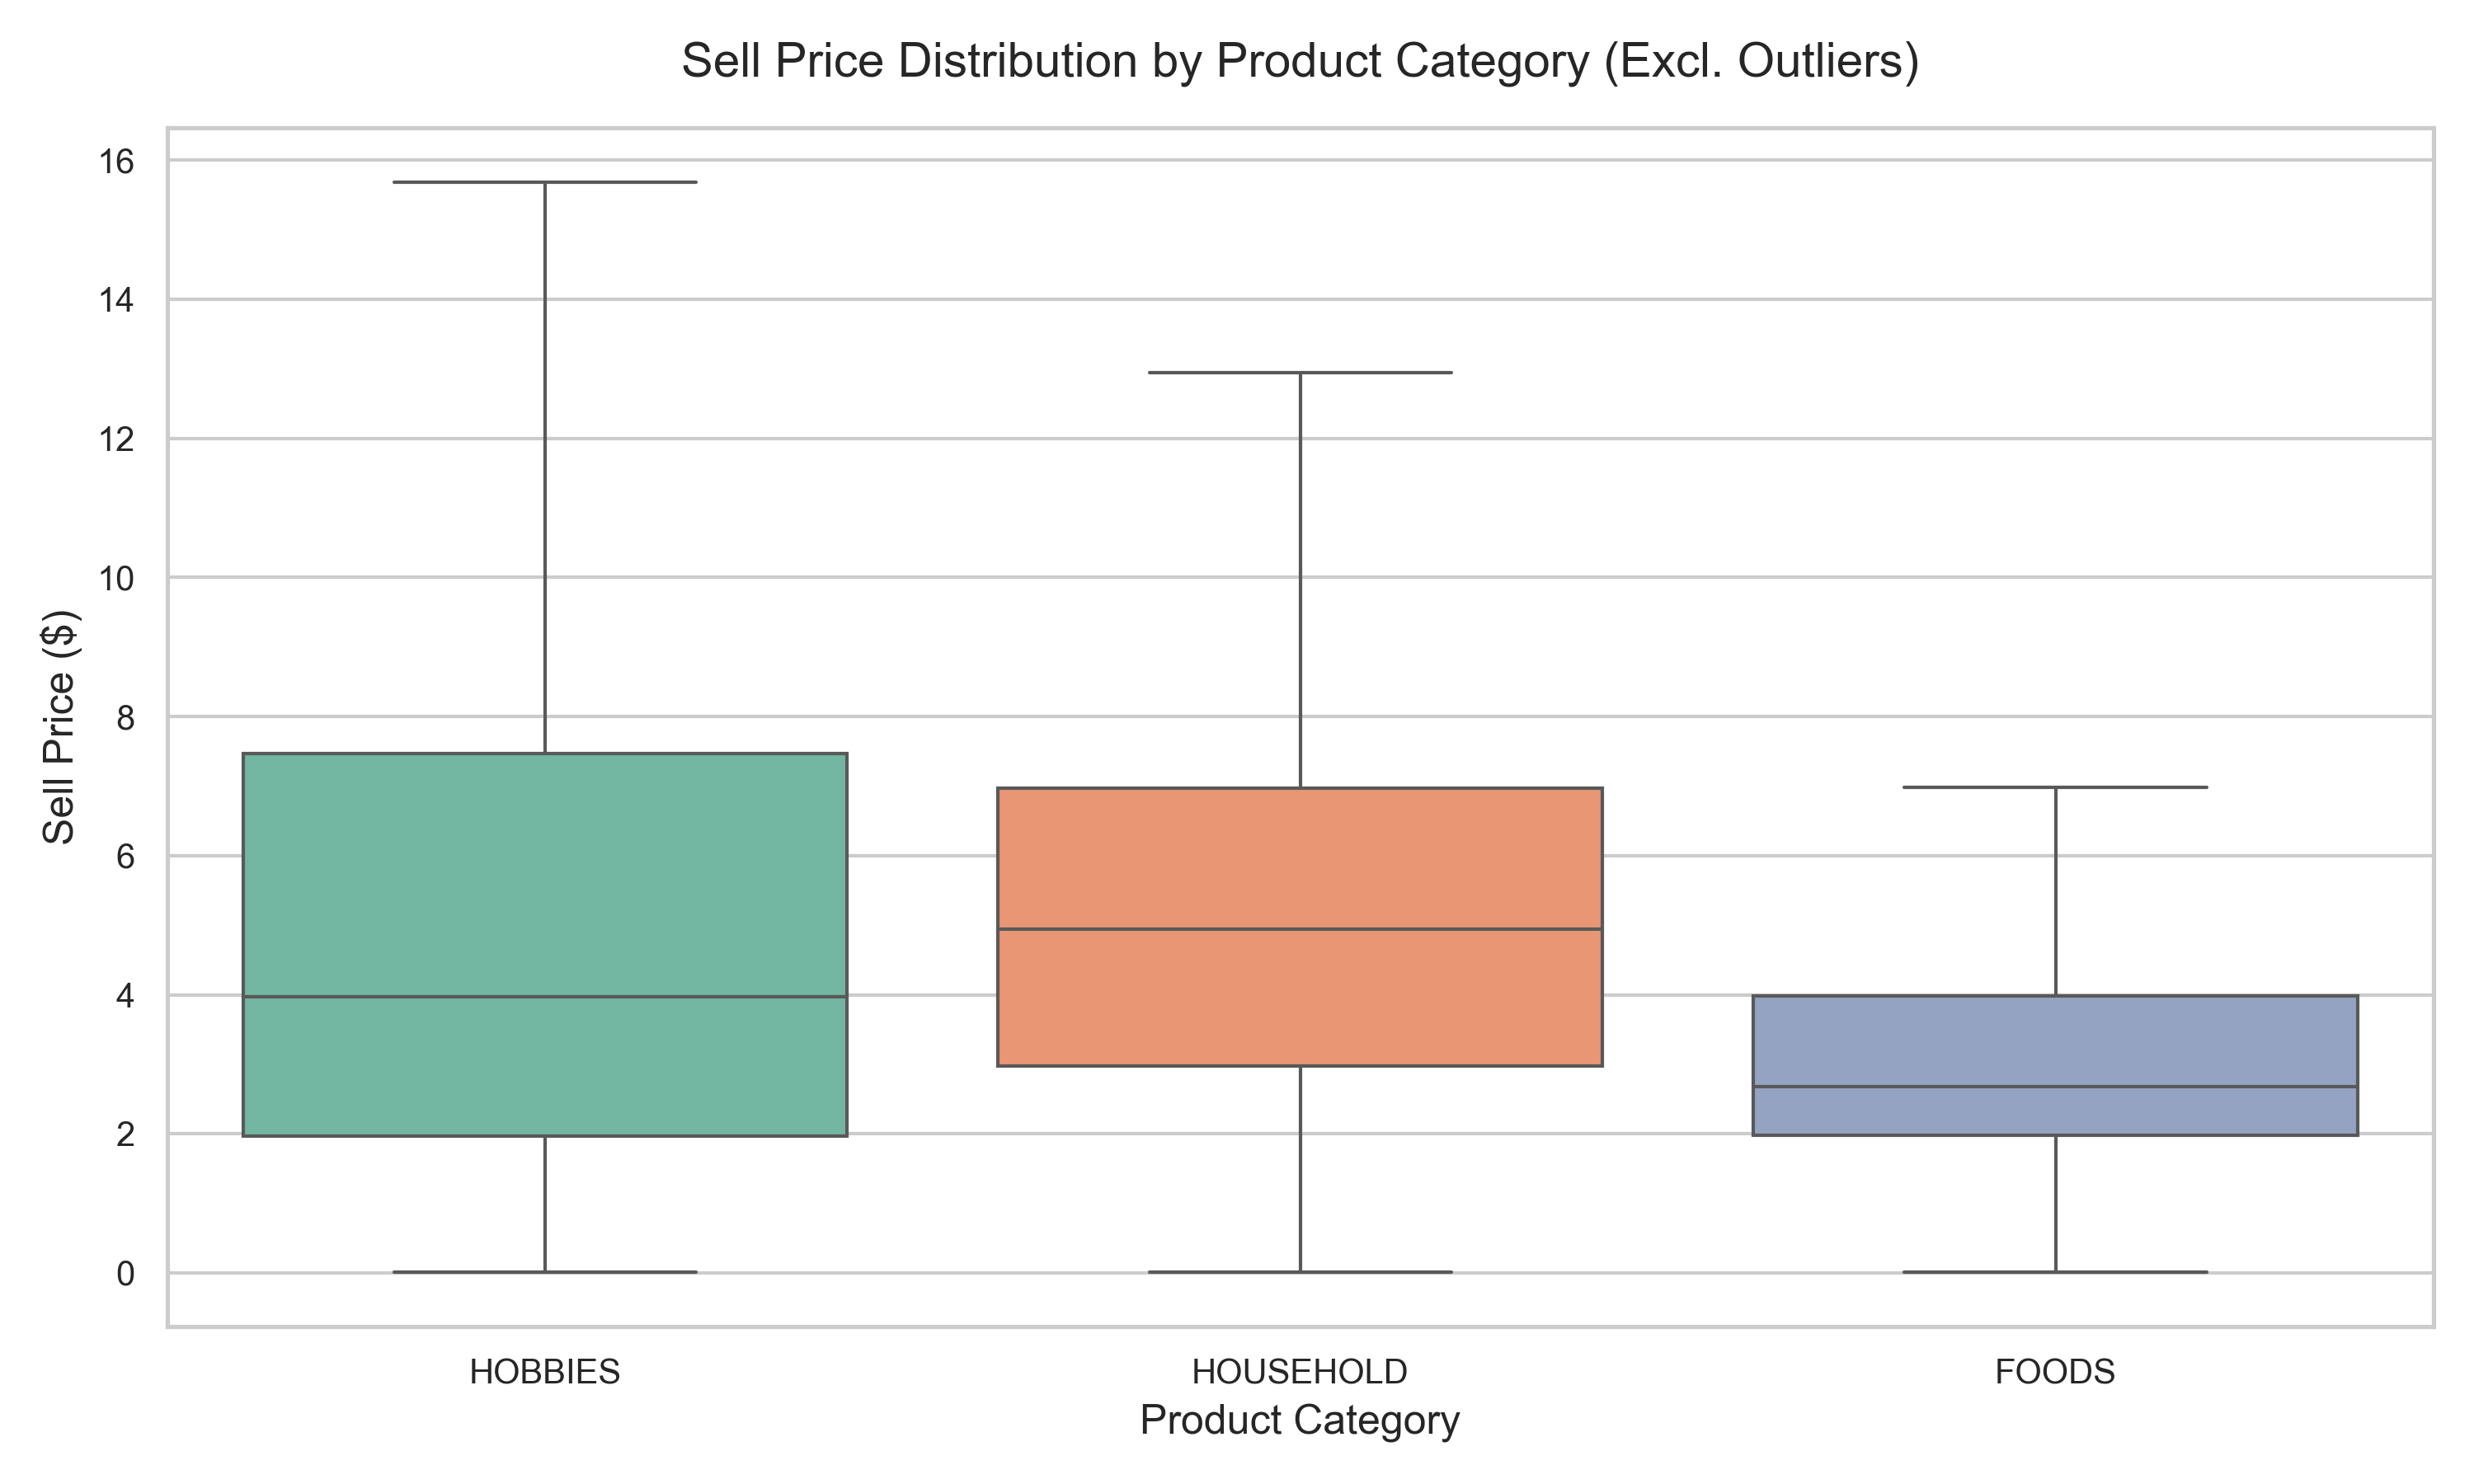

=== 4. Impact of SNAP Purchase Days on Average Sales ===


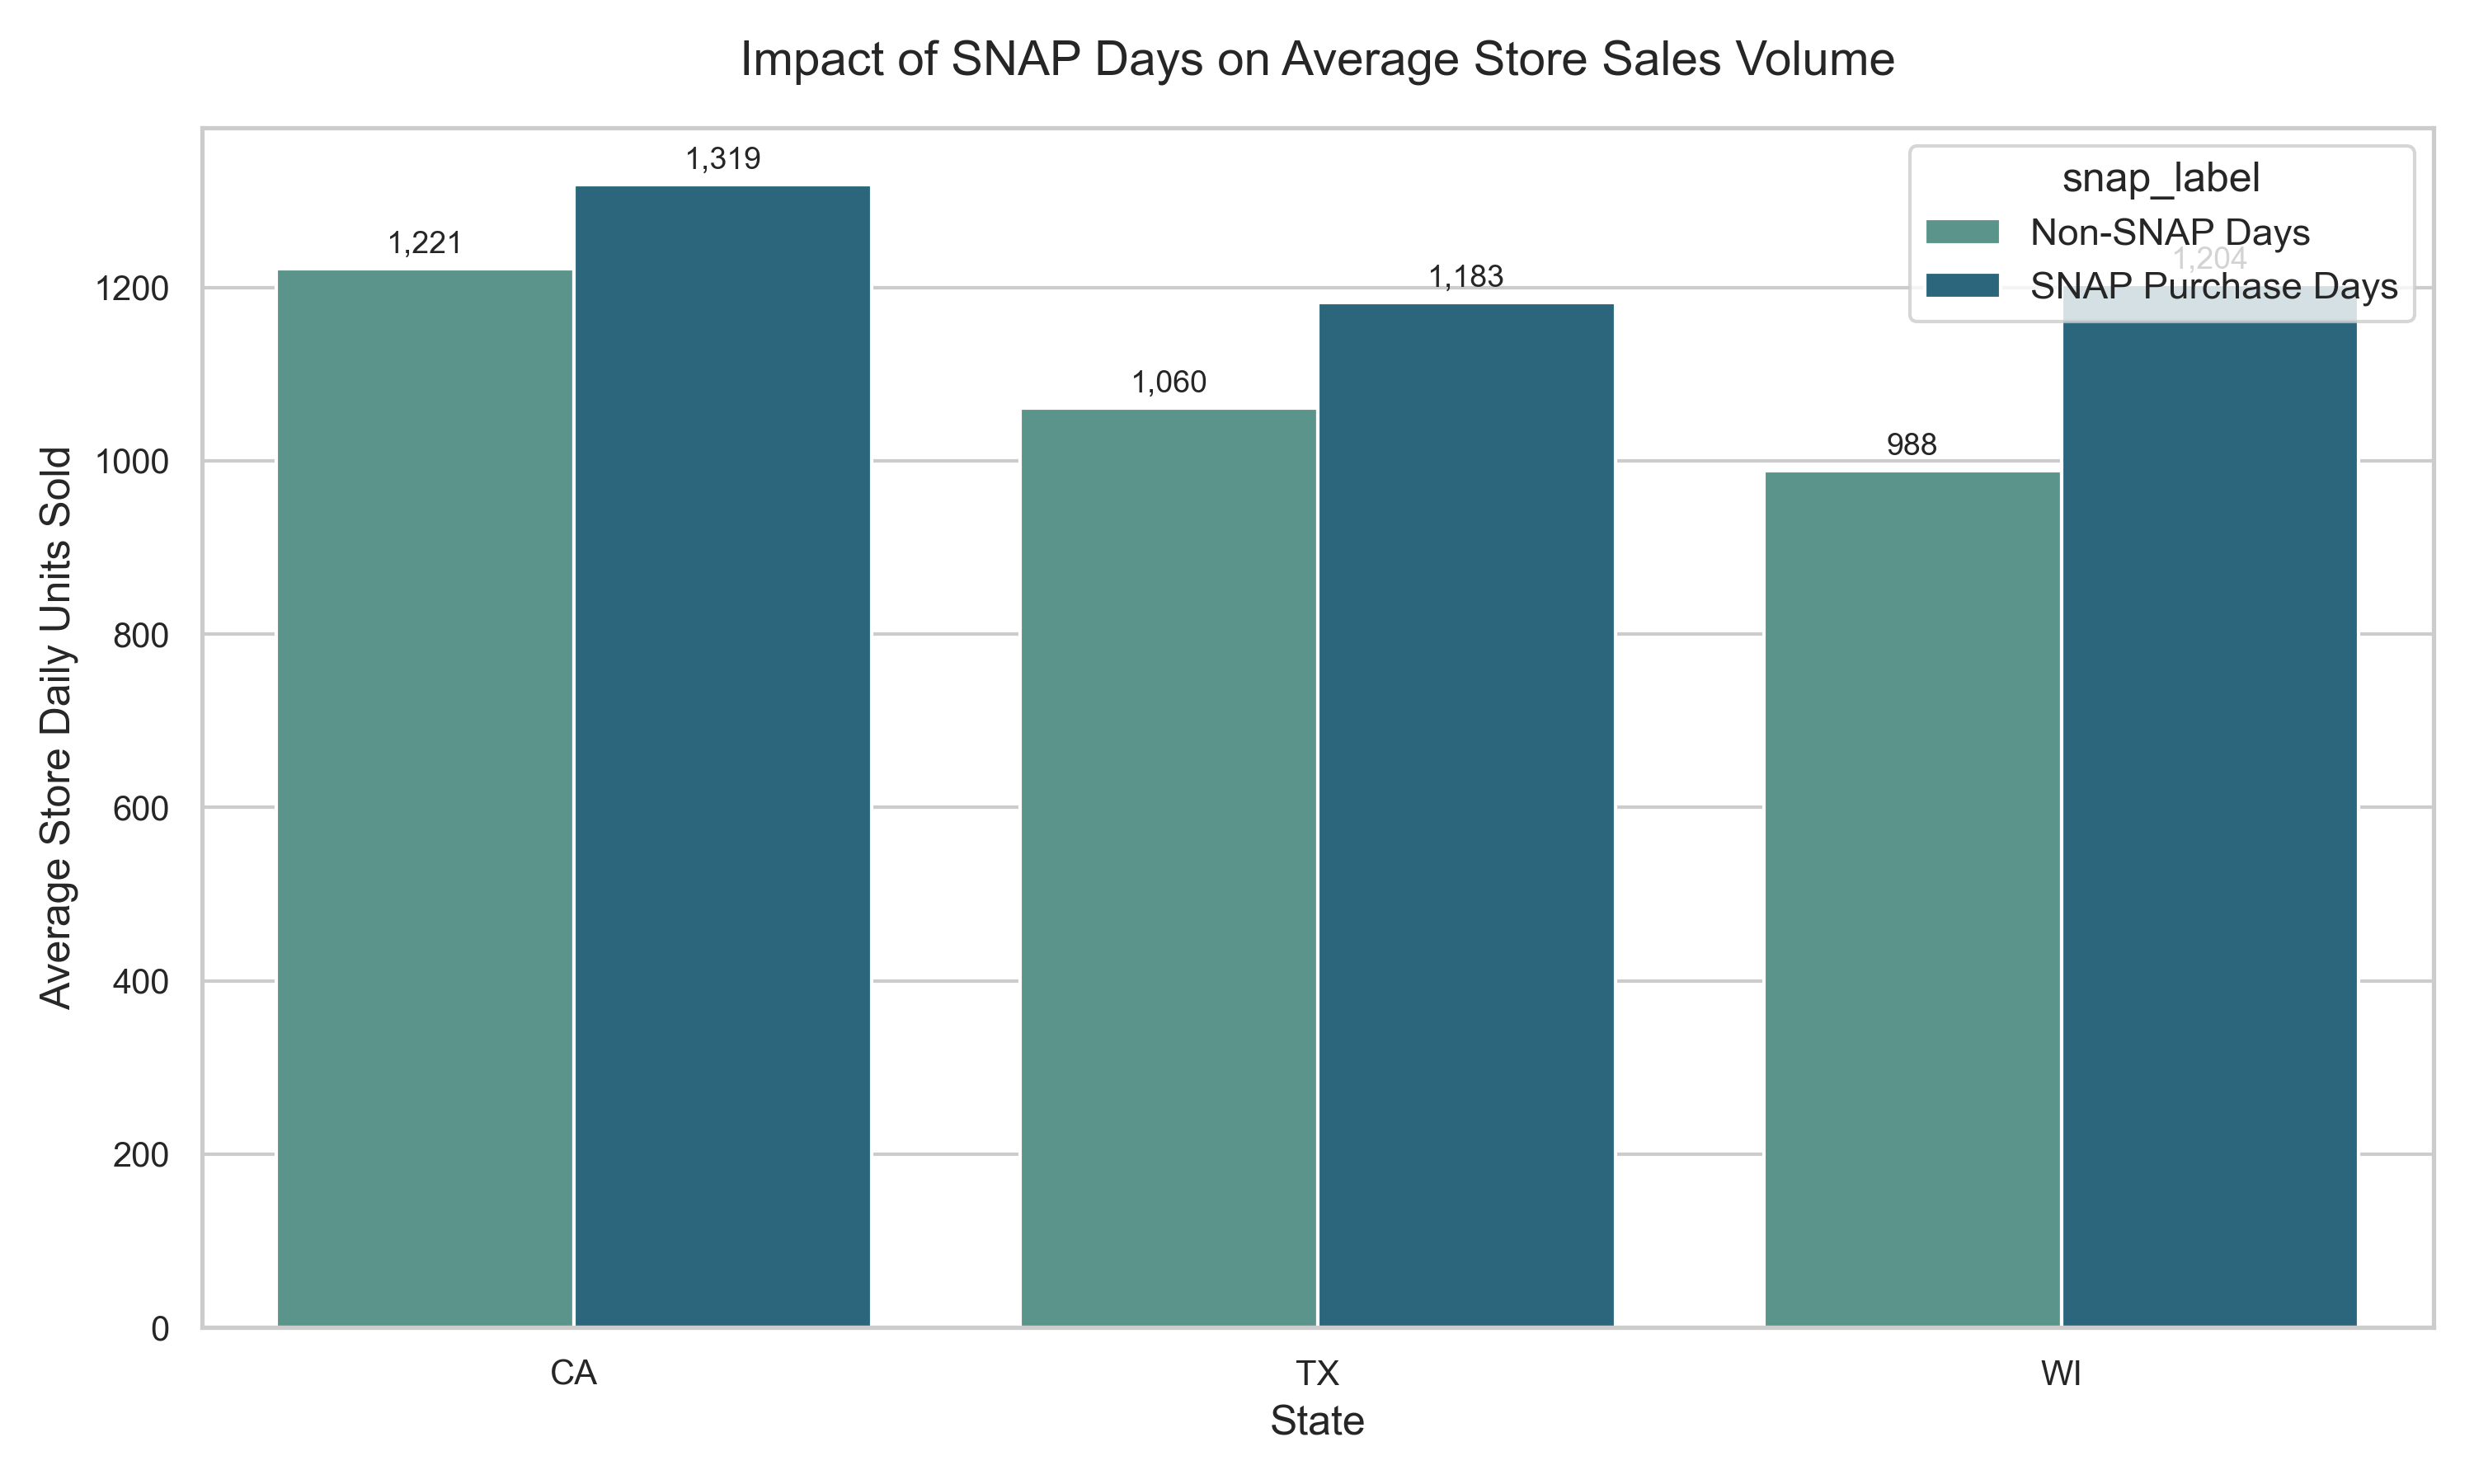

=== 5. Sales Impact of Key Calendar Events & Holidays ===


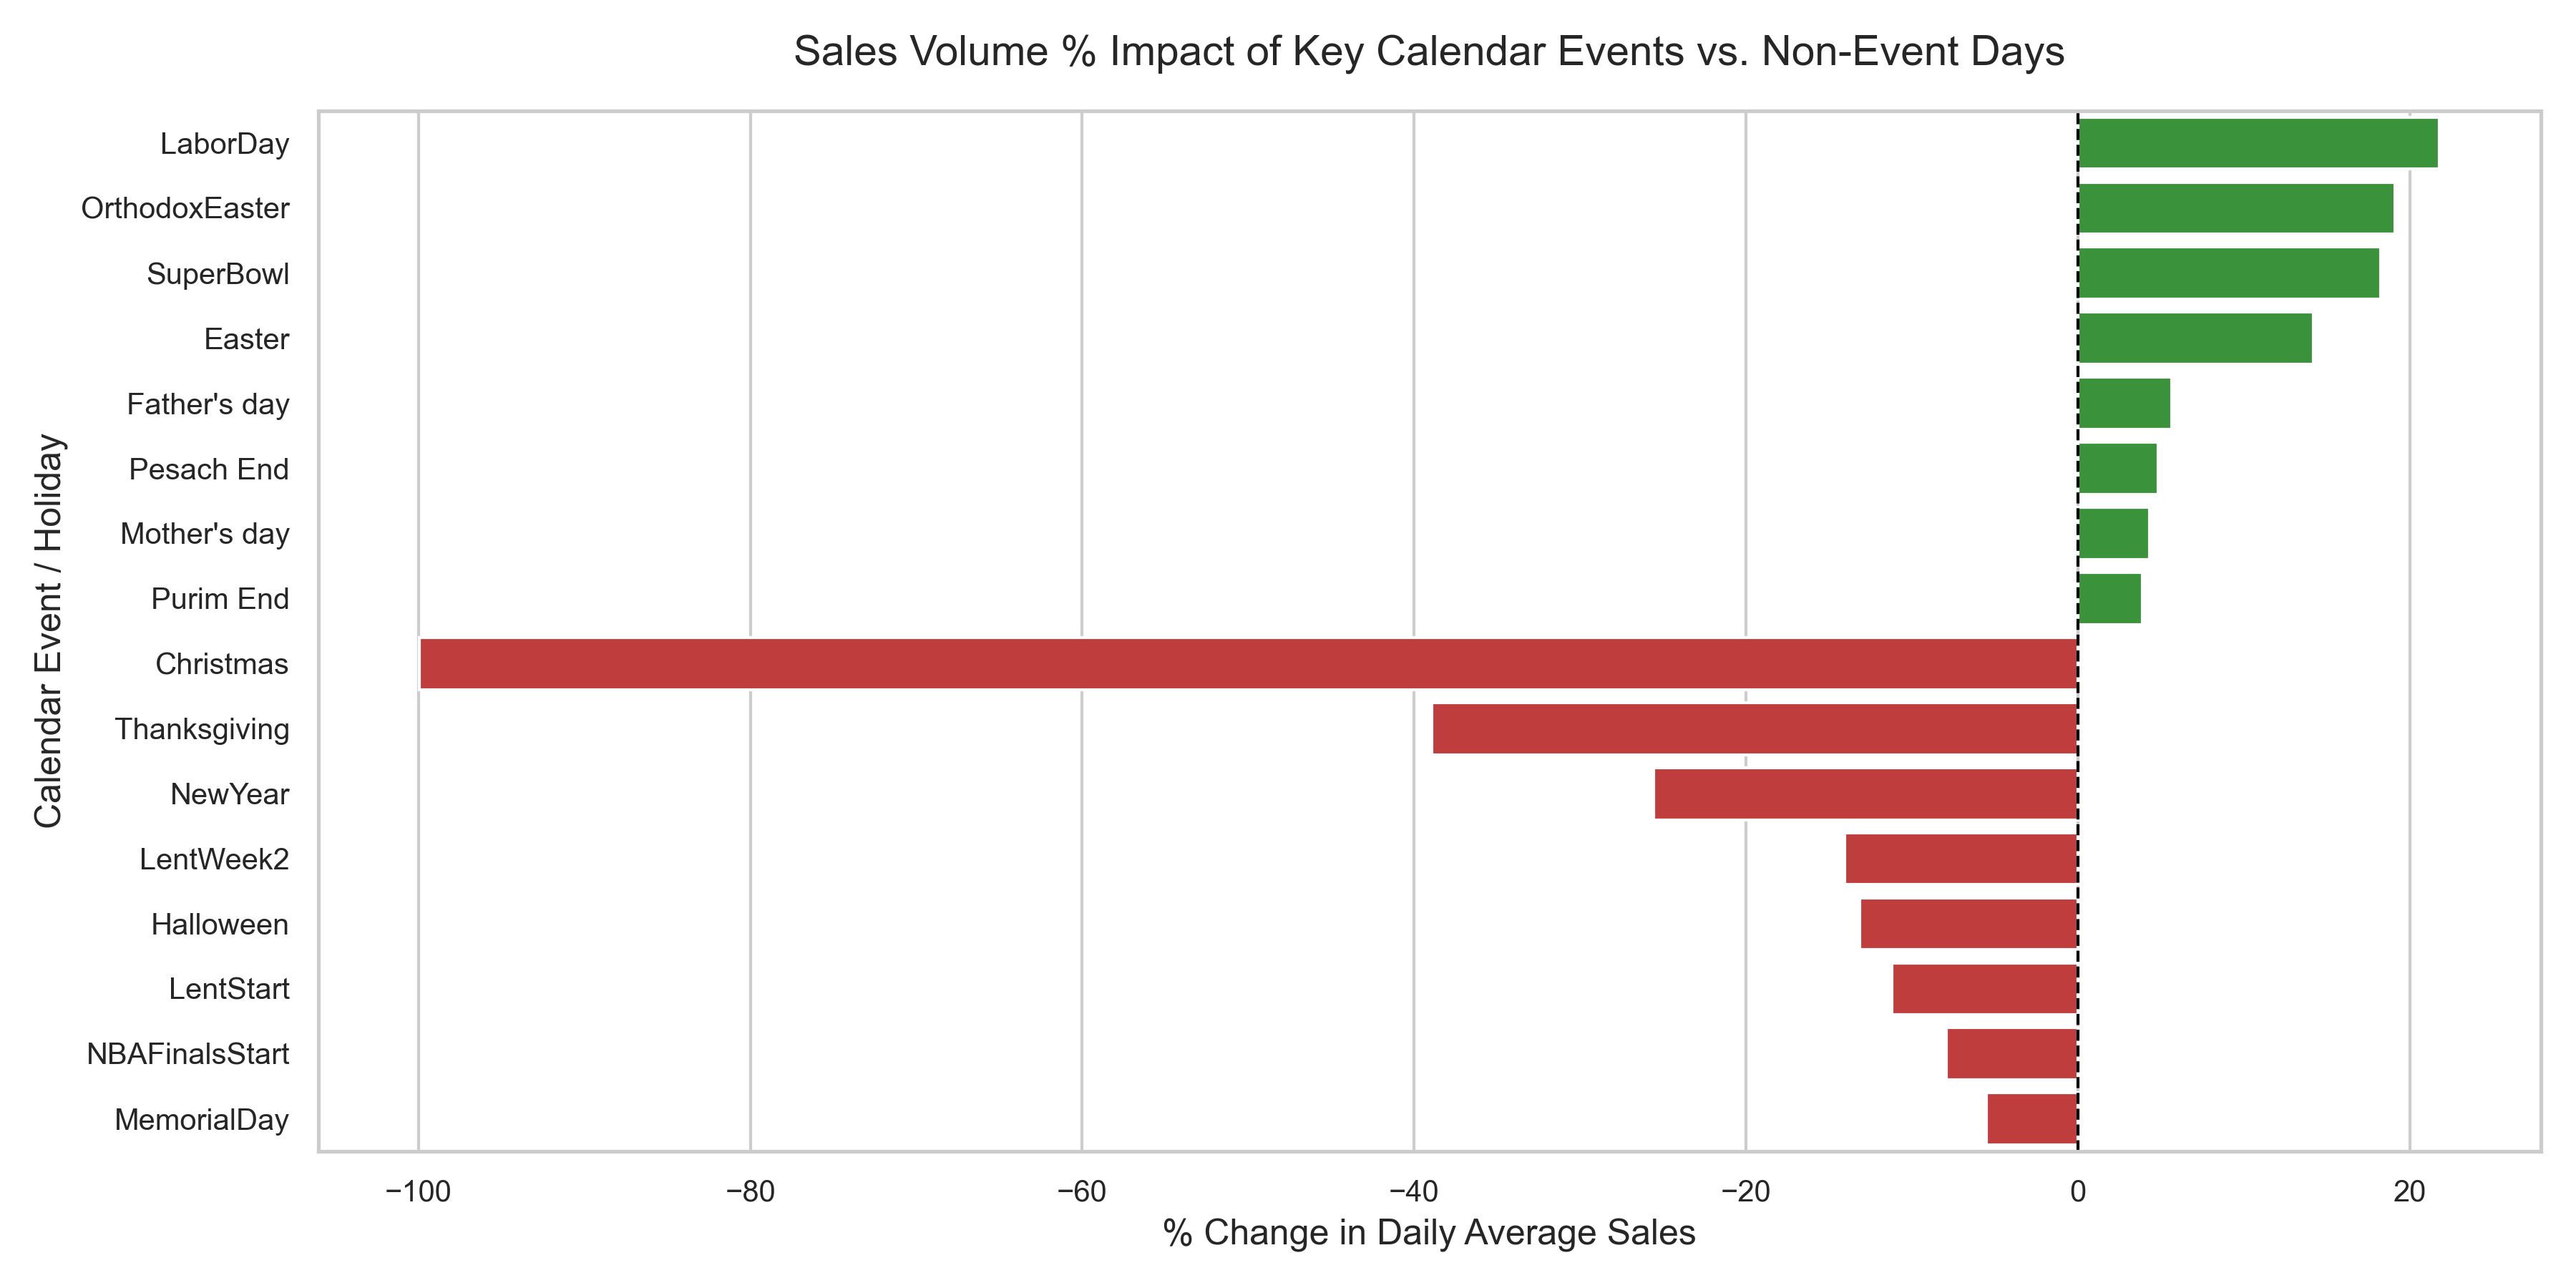

=== 6. Top 10 Best vs. Bottom 10 Lowest Selling Products ===


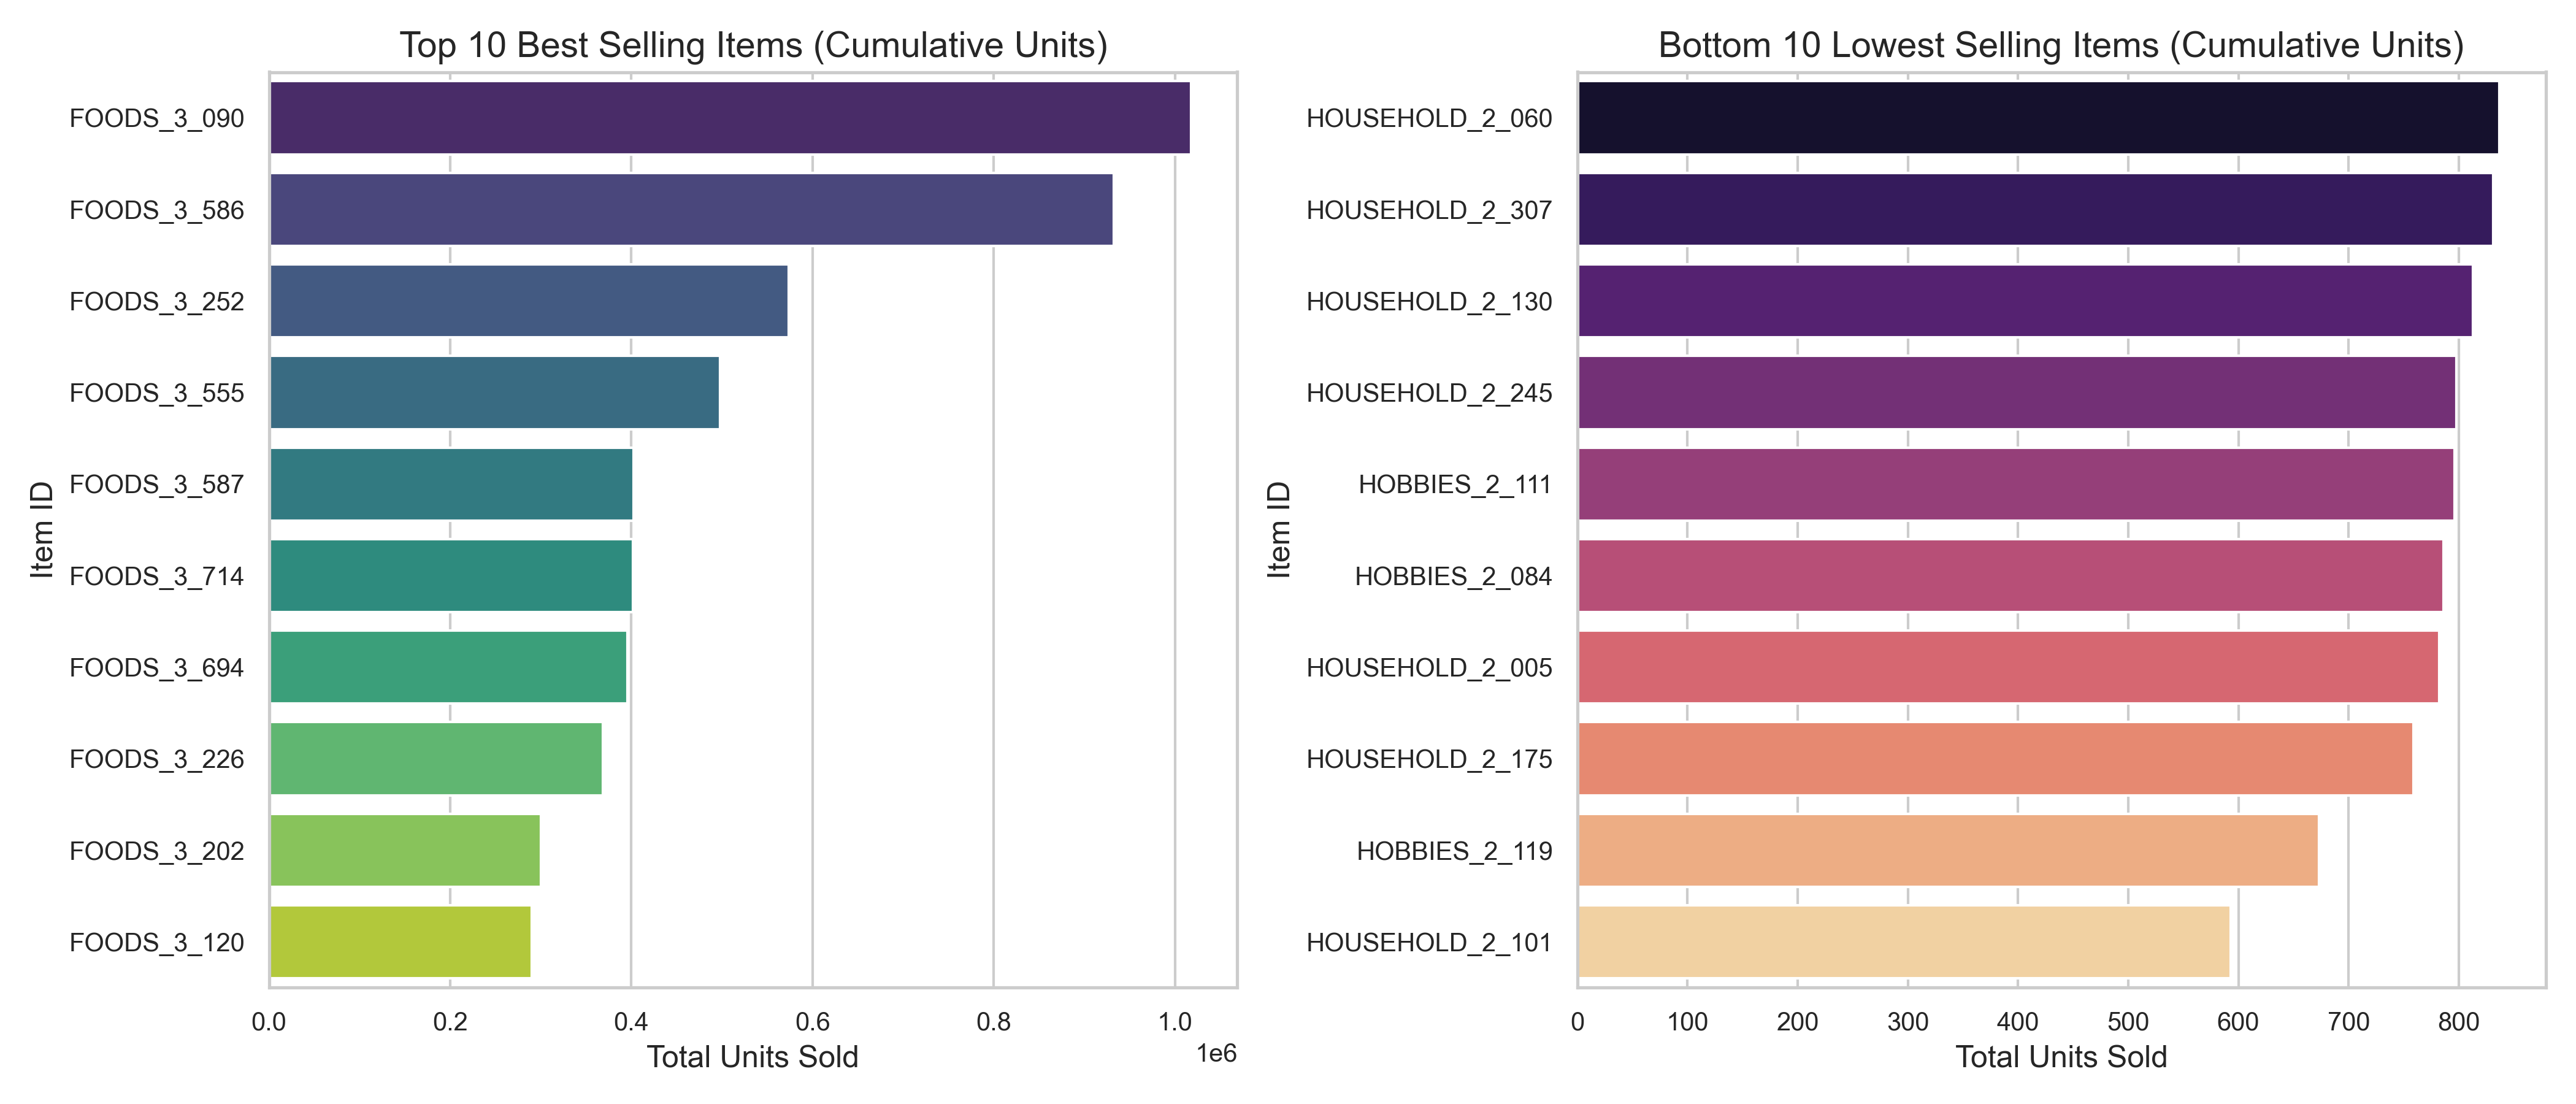

=== 7. Seasonality Heatmap: Day of Week vs. Month ===


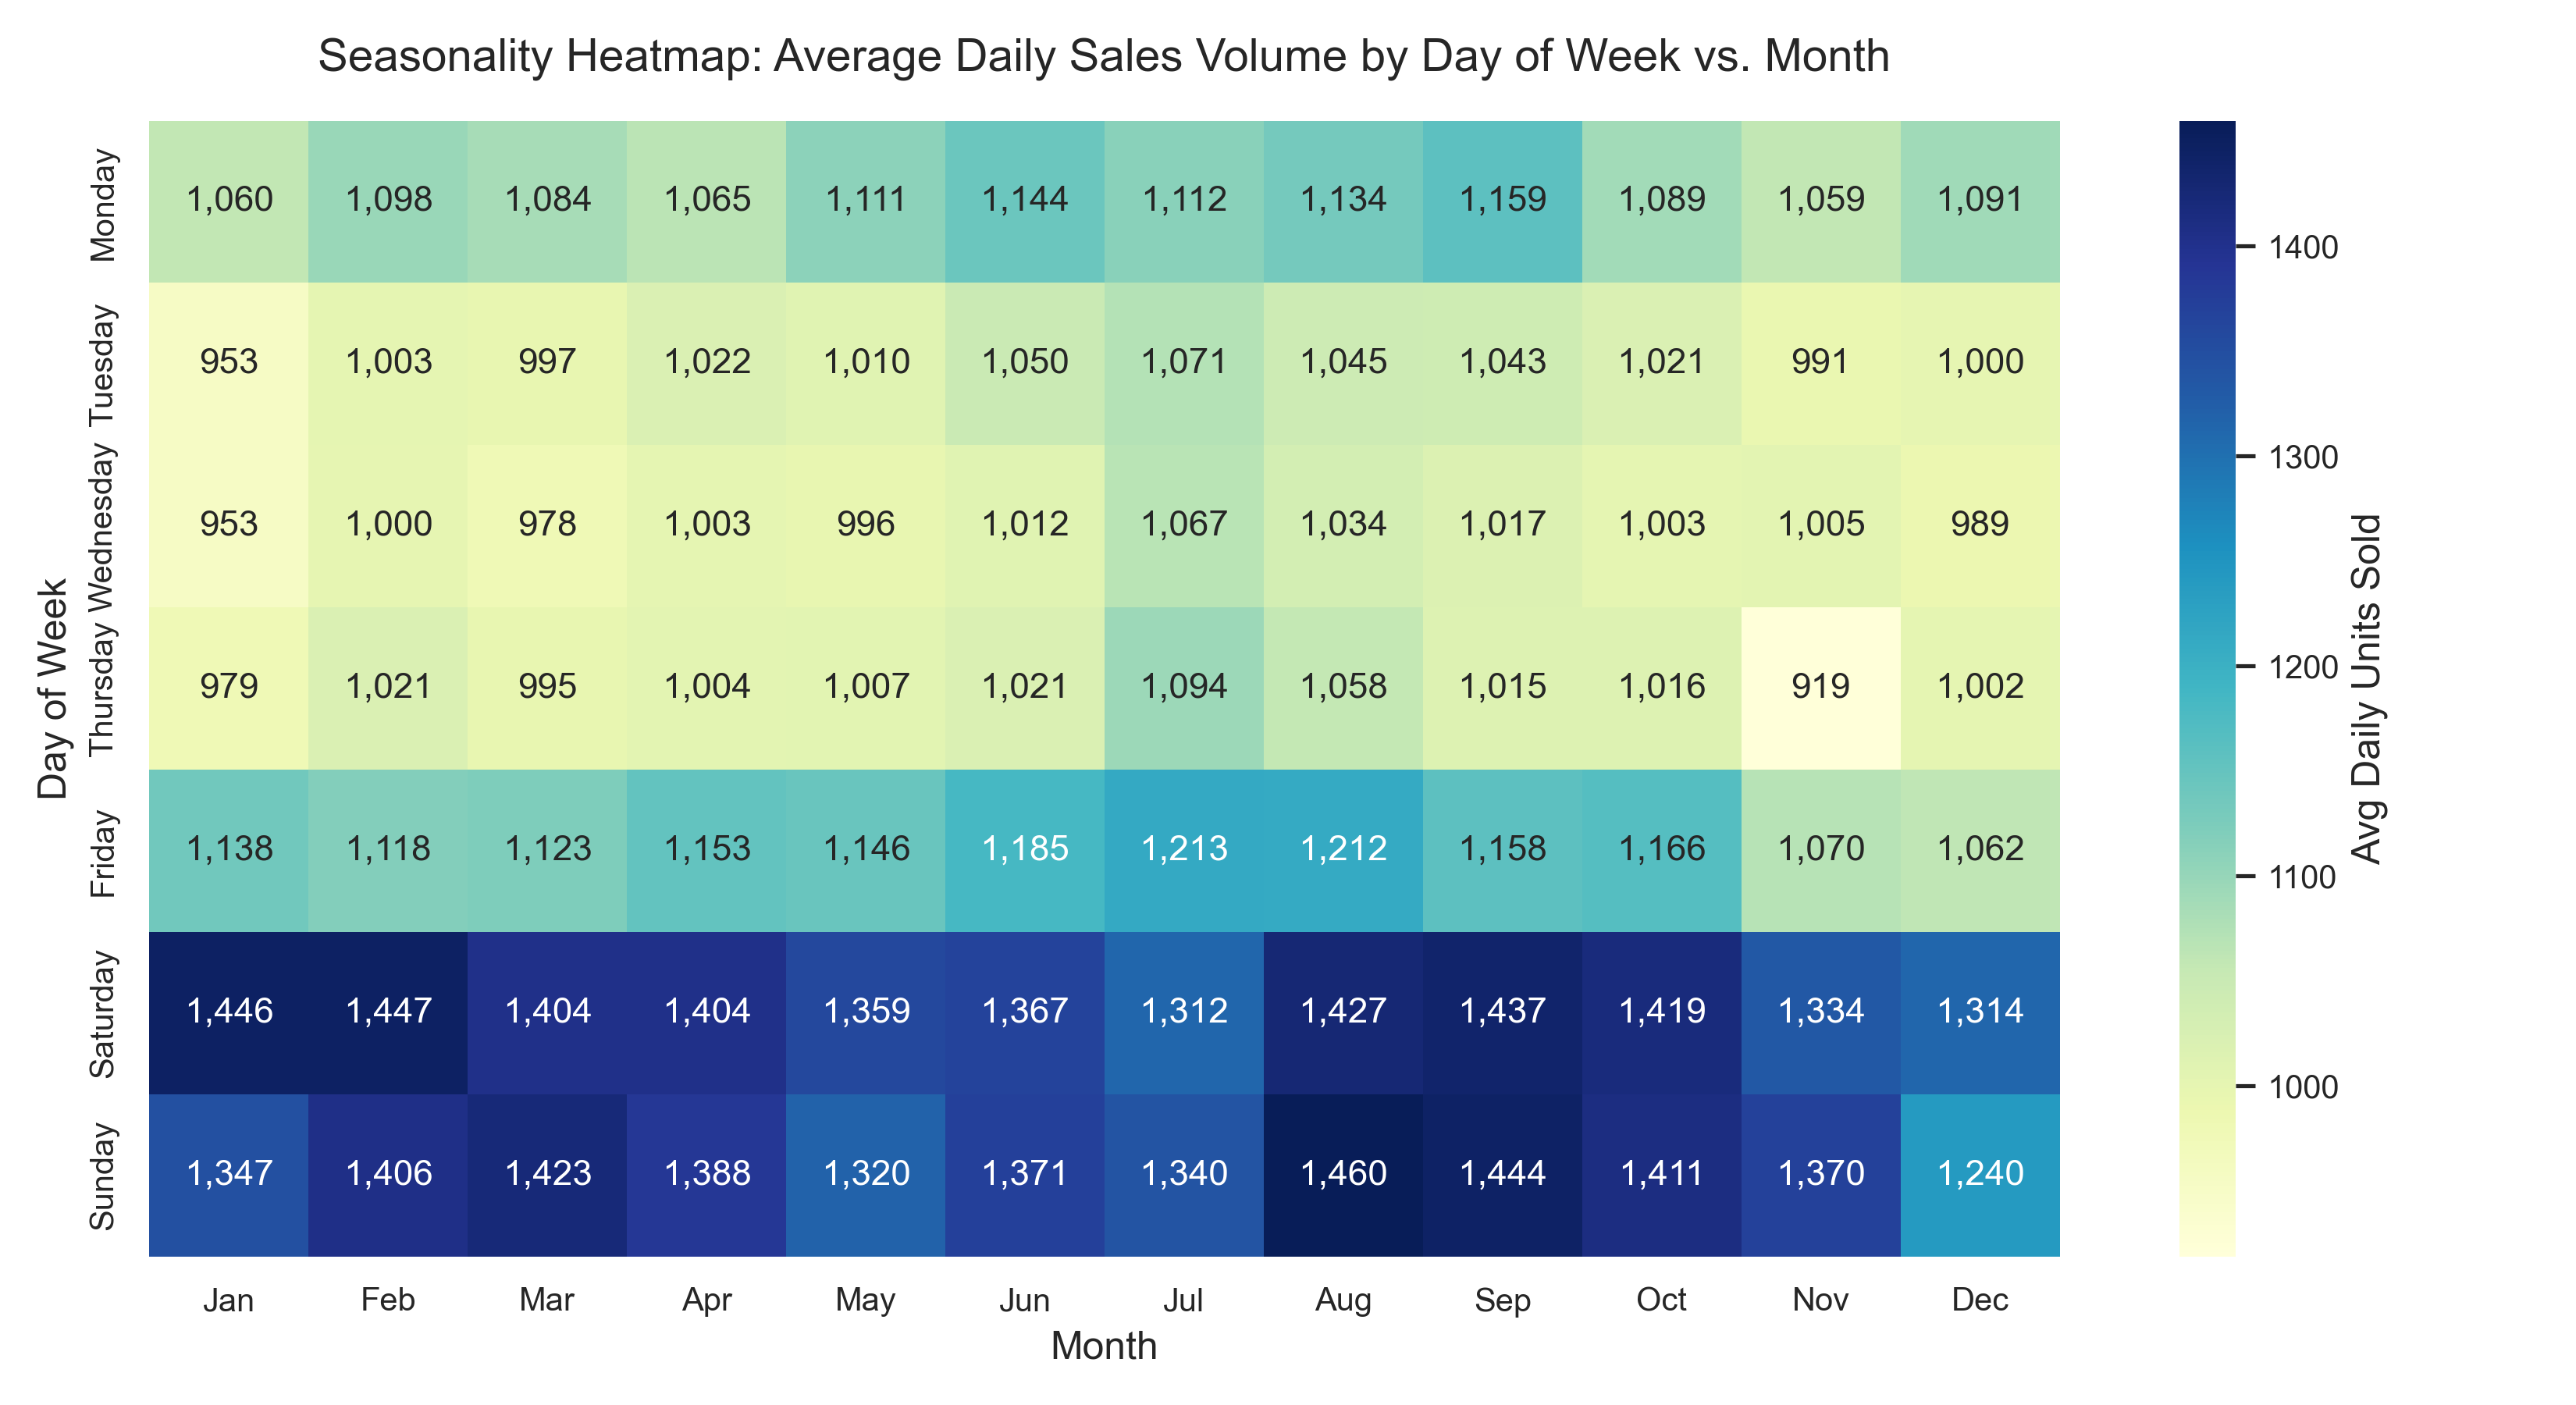

In [8]:
# Display all generated charts
charts = [
    ("total_sales_over_time.png", "1. Aggregate Daily & 28-Day Rolling Average Sales"),
    ("sales_by_category_state.png", "2. Total Unit Sales by Category & State"),
    ("price_distribution_by_category.png", "3. Sell Price Distribution by Category"),
    ("snap_impact_analysis.png", "4. Impact of SNAP Purchase Days on Average Sales"),
    ("event_sales_impact.png", "5. Sales Impact of Key Calendar Events & Holidays"),
    ("top_bottom_selling_items.png", "6. Top 10 Best vs. Bottom 10 Lowest Selling Products"),
    ("weekly_seasonality_heatmap.png", "7. Seasonality Heatmap: Day of Week vs. Month")
]

for filename, title in charts:
    chart_path = os.path.join(CHARTS_DIR, filename)
    if os.path.exists(chart_path):
        print(f"=== {title} ===")
        display(Image(filename=chart_path))
    else:
        print(f"Chart file not found: {chart_path}")


## Summary & Deliverable Check

Cleaned datasets exported to `data/cleaned/`:
- `calendar_clean.parquet` / `.csv`
- `sell_prices_clean.parquet` / `.csv`
- `sales_train_evaluation_clean.parquet` / `.csv`

All 7 tasks completed successfully!
